# Uji Coba Model Bounding Box - Perbandingan Loss Function
Eksperimen sederhana: bandingkan beberapa **loss function bounding box yang sudah umum dipakai** (bukan yang advanced/eksotis) - Smooth L1, MSE, IoU Loss, GIoU Loss, DIoU Loss, CIoU Loss.

**Setup:** tanpa mount Drive - dataset diambil langsung dari Kaggle via API (`kaggle.json`).

**Model:** backbone pretrained MobileNetV2 (ringan, cukup buat uji coba) + head regresi 4 koordinat box per gambar. Ini BUKAN detector multi-object penuh (bukan YOLO/Faster-RCNN) - fokusnya sengaja disederhanakan ke satu box per gambar supaya perbandingan loss function-nya bersih, bukan tercampur isu arsitektur detection.

**Dataset:** [Dog and Cat Detection](https://www.kaggle.com/datasets/andrewmvd/dog-and-cat-detection) (Kaggle) - anotasi format Pascal VOC (XML). Kalau satu gambar punya >1 objek, diambil objek pertama saja demi kesederhanaan single-box regression.

| Tahap | Estimasi (GPU T4/L4) |
|---|---|
| Download + parsing dataset | ~2 mnt |
| Training per loss function (15 epoch, img 224, backbone frozen) | ~3-5 mnt |
| Total (6 loss function) | ~20-30 mnt |

Catatan: karena tanpa mount Drive, semua hasil (model, gambar) cuma hidup selama sesi Colab. Download manual lewat panel Files kalau mau disimpan.

In [1]:
# ==== 1. SETUP KAGGLE API (tanpa mount Drive) ====
# kaggle.json didapat dari kaggle.com -> Account -> Create New API Token
from google.colab import files
import os

if not os.path.exists('/root/.kaggle/kaggle.json'):
    print('Upload kaggle.json:')
    uploaded = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    !cp kaggle.json /root/.kaggle/kaggle.json
    !chmod 600 /root/.kaggle/kaggle.json

!pip install -q kaggle
!kaggle datasets download -d andrewmvd/dog-and-cat-detection -p /content/data --unzip
print('isi /content/data:', os.listdir('/content/data'))

Upload kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/dog-and-cat-detection
License(s): CC-BY-SA-4.0
100% 1.03G/1.03G [00:58<00:00, 18.8MB/s]

isi /content/data: ['annotations', 'images']


In [2]:
# ==== 2. PARSING ANOTASI (Pascal VOC XML) -> DataFrame ====
import glob, xml.etree.ElementTree as ET
import pandas as pd

IMG_DIR = '/content/data/images'
ANN_DIR = '/content/data/annotations'

rows = []
for ann_path in glob.glob(os.path.join(ANN_DIR, '*.xml')):
    root = ET.parse(ann_path).getroot()
    filename = root.find('filename').text
    w = int(root.find('size/width').text)
    h = int(root.find('size/height').text)
    obj = root.find('object')  # ambil objek pertama saja (simplifikasi single-box)
    if obj is None:
        continue
    box = obj.find('bndbox')
    xmin, ymin = int(float(box.find('xmin').text)), int(float(box.find('ymin').text))
    xmax, ymax = int(float(box.find('xmax').text)), int(float(box.find('ymax').text))
    img_path = os.path.join(IMG_DIR, filename)
    if not os.path.exists(img_path):
        continue
    rows.append({'path': img_path, 'width': w, 'height': h,
                 'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax})

df = pd.DataFrame(rows)
print('total sampel dengan bbox valid:', len(df))
df.head()

total sampel dengan bbox valid: 3686


,path,width,height,xmin,ymin,xmax,ymax
0,/content/data/images/Cats_Test3017.png,333,500,133,150,332,291
1,/content/data/images/Cats_Test724.png,358,500,61,99,357,440
2,/content/data/images/Cats_Test743.png,351,500,144,105,269,239
3,/content/data/images/Cats_Test1660.png,500,334,213,27,394,209
4,/content/data/images/Cats_Test243.png,358,500,50,48,228,265


In [3]:
# ==== 3. SPLIT + tf.data PIPELINE (resize + normalisasi koordinat ke [0,1]) ====
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

IMG_SIZE = 224
BATCH_SIZE = 16

train_df, val_df = train_test_split(df, test_size=0.15, random_state=42)
print('train:', len(train_df), '| val:', len(val_df))

def load_sample(path, w, h, xmin, ymin, xmax, ymax):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0

    # normalisasi bbox ke [0,1] relatif ukuran gambar ASLI - konsisten dengan hasil resize
    box = tf.stack([
        tf.cast(xmin, tf.float32) / tf.cast(w, tf.float32),
        tf.cast(ymin, tf.float32) / tf.cast(h, tf.float32),
        tf.cast(xmax, tf.float32) / tf.cast(w, tf.float32),
        tf.cast(ymax, tf.float32) / tf.cast(h, tf.float32),
    ])
    return img, box

def make_ds(d, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        d['path'].values, d['width'].values, d['height'].values,
        d['xmin'].values, d['ymin'].values, d['xmax'].values, d['ymax'].values,
    ))
    if shuffle:
        ds = ds.shuffle(len(d))
    ds = ds.map(load_sample, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(train_df, shuffle=True)
val_ds = make_ds(val_df)

train: 3133 | val: 553


In [4]:
# ==== 4. MODEL: backbone ringan (frozen) + head regresi 4 koordinat ====
def build_model():
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base.trainable = False

    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(4, activation='sigmoid')(x)

    return tf.keras.Model(base.input, out)

build_model().summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
# ==== 5. LOSS FUNCTION BOUNDING BOX (formula standar - IoU/GIoU/DIoU/CIoU) ====
def compute_iou(y_true, y_pred, eps=1e-7):
    x1 = tf.maximum(y_true[..., 0], y_pred[..., 0])
    y1 = tf.maximum(y_true[..., 1], y_pred[..., 1])
    x2 = tf.minimum(y_true[..., 2], y_pred[..., 2])
    y2 = tf.minimum(y_true[..., 3], y_pred[..., 3])
    inter = tf.maximum(0.0, x2 - x1) * tf.maximum(0.0, y2 - y1)

    area_t = tf.maximum(0.0, y_true[..., 2] - y_true[..., 0]) * tf.maximum(0.0, y_true[..., 3] - y_true[..., 1])
    area_p = tf.maximum(0.0, y_pred[..., 2] - y_pred[..., 0]) * tf.maximum(0.0, y_pred[..., 3] - y_pred[..., 1])
    union = area_t + area_p - inter + eps
    iou = inter / union
    return iou, union

def mean_iou(y_true, y_pred):
    iou, _ = compute_iou(y_true, y_pred)
    return tf.reduce_mean(iou)

def smooth_l1_loss(y_true, y_pred, beta=1.0):
    diff = tf.abs(y_true - y_pred)
    loss = tf.where(diff < beta, 0.5 * tf.square(diff) / beta, diff - 0.5 * beta)
    return tf.reduce_mean(loss, axis=-1)

def iou_loss(y_true, y_pred):
    iou, _ = compute_iou(y_true, y_pred)
    return 1.0 - iou

def giou_loss(y_true, y_pred, eps=1e-7):
    iou, union = compute_iou(y_true, y_pred, eps)
    xc1 = tf.minimum(y_true[..., 0], y_pred[..., 0])
    yc1 = tf.minimum(y_true[..., 1], y_pred[..., 1])
    xc2 = tf.maximum(y_true[..., 2], y_pred[..., 2])
    yc2 = tf.maximum(y_true[..., 3], y_pred[..., 3])
    area_c = (xc2 - xc1) * (yc2 - yc1) + eps
    giou = iou - (area_c - union) / area_c
    return 1.0 - giou

def diou_loss(y_true, y_pred, eps=1e-7):
    iou, _ = compute_iou(y_true, y_pred, eps)
    xc1 = tf.minimum(y_true[..., 0], y_pred[..., 0])
    yc1 = tf.minimum(y_true[..., 1], y_pred[..., 1])
    xc2 = tf.maximum(y_true[..., 2], y_pred[..., 2])
    yc2 = tf.maximum(y_true[..., 3], y_pred[..., 3])
    c2 = tf.square(xc2 - xc1) + tf.square(yc2 - yc1) + eps  # diagonal enclosing box

    cx_t = (y_true[..., 0] + y_true[..., 2]) / 2
    cy_t = (y_true[..., 1] + y_true[..., 3]) / 2
    cx_p = (y_pred[..., 0] + y_pred[..., 2]) / 2
    cy_p = (y_pred[..., 1] + y_pred[..., 3]) / 2
    rho2 = tf.square(cx_t - cx_p) + tf.square(cy_t - cy_p)

    diou = iou - rho2 / c2
    return 1.0 - diou

def ciou_loss(y_true, y_pred, eps=1e-7):
    iou, _ = compute_iou(y_true, y_pred, eps)
    xc1 = tf.minimum(y_true[..., 0], y_pred[..., 0])
    yc1 = tf.minimum(y_true[..., 1], y_pred[..., 1])
    xc2 = tf.maximum(y_true[..., 2], y_pred[..., 2])
    yc2 = tf.maximum(y_true[..., 3], y_pred[..., 3])
    c2 = tf.square(xc2 - xc1) + tf.square(yc2 - yc1) + eps

    cx_t = (y_true[..., 0] + y_true[..., 2]) / 2
    cy_t = (y_true[..., 1] + y_true[..., 3]) / 2
    cx_p = (y_pred[..., 0] + y_pred[..., 2]) / 2
    cy_p = (y_pred[..., 1] + y_pred[..., 3]) / 2
    rho2 = tf.square(cx_t - cx_p) + tf.square(cy_t - cy_p)

    w_t = y_true[..., 2] - y_true[..., 0]
    h_t = y_true[..., 3] - y_true[..., 1]
    w_p = y_pred[..., 2] - y_pred[..., 0]
    h_p = y_pred[..., 3] - y_pred[..., 1]

    v = (4.0 / (np.pi ** 2)) * tf.square(tf.atan(w_t / (h_t + eps)) - tf.atan(w_p / (h_p + eps)))
    alpha = v / (1.0 - iou + v + eps)

    ciou = iou - (rho2 / c2 + alpha * v)
    return 1.0 - ciou

In [6]:
# ==== 6. TRAIN + EVALUASI TIAP LOSS FUNCTION ====
EPOCHS = 10

loss_functions = {
    'MSE (baseline)': 'mse',
    'Smooth L1': smooth_l1_loss,
    'IoU Loss': iou_loss,
    'GIoU Loss': giou_loss,
    'DIoU Loss': diou_loss,
    'CIoU Loss': ciou_loss,
}

results = []
trained_models = {}
for nama, loss_fn in loss_functions.items():
    print(f'\n=== Training dengan {nama} ===')
    model = build_model()
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=loss_fn, metrics=[mean_iou])
    hist = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=0)

    val_iou = hist.history['val_mean_iou'][-1]
    val_loss = hist.history['val_loss'][-1]
    results.append({'loss_function': nama, 'val_iou': val_iou, 'val_loss': val_loss})
    trained_models[nama] = model
    print(f'{nama}: val_loss={val_loss:.4f} | val_mean_IoU={val_iou:.4f}')


=== Training dengan MSE (baseline) ===
MSE (baseline): val_loss=0.0140 | val_mean_IoU=0.4306

=== Training dengan Smooth L1 ===
Smooth L1: val_loss=0.0068 | val_mean_IoU=0.4414

=== Training dengan IoU Loss ===
IoU Loss: val_loss=0.5436 | val_mean_IoU=0.4559

=== Training dengan GIoU Loss ===
GIoU Loss: val_loss=1.0000 | val_mean_IoU=0.0000

=== Training dengan DIoU Loss ===
DIoU Loss: val_loss=0.5847 | val_mean_IoU=0.4513

=== Training dengan CIoU Loss ===
CIoU Loss: val_loss=1.1089 | val_mean_IoU=0.0000


    loss_function   val_iou  val_loss
0        IoU Loss  0.455936  0.543619
1       DIoU Loss  0.451261  0.584686
2       Smooth L1  0.441378  0.006768
3  MSE (baseline)  0.430570  0.014031
4       GIoU Loss  0.000000  1.000000
5       CIoU Loss  0.000000  1.108936


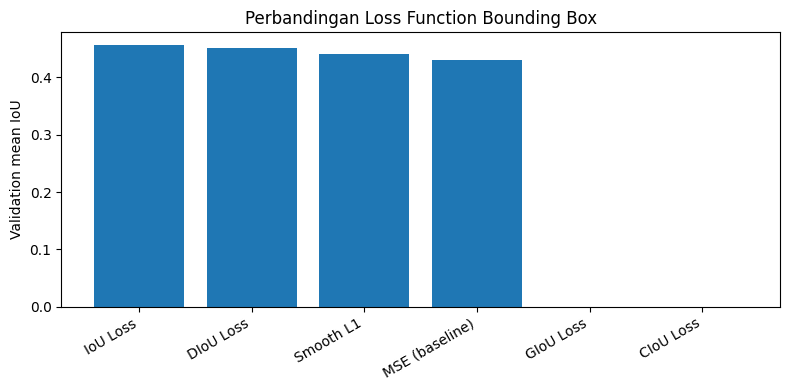

In [7]:
# ==== 7. TABEL PERBANDINGAN ====
res_df = pd.DataFrame(results).sort_values('val_iou', ascending=False).reset_index(drop=True)
print(res_df)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.bar(res_df['loss_function'], res_df['val_iou'])
plt.ylabel('Validation mean IoU')
plt.title('Perbandingan Loss Function Bounding Box')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('/content/perbandingan_loss.png', dpi=150)
plt.show()

loss function terbaik: IoU Loss
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


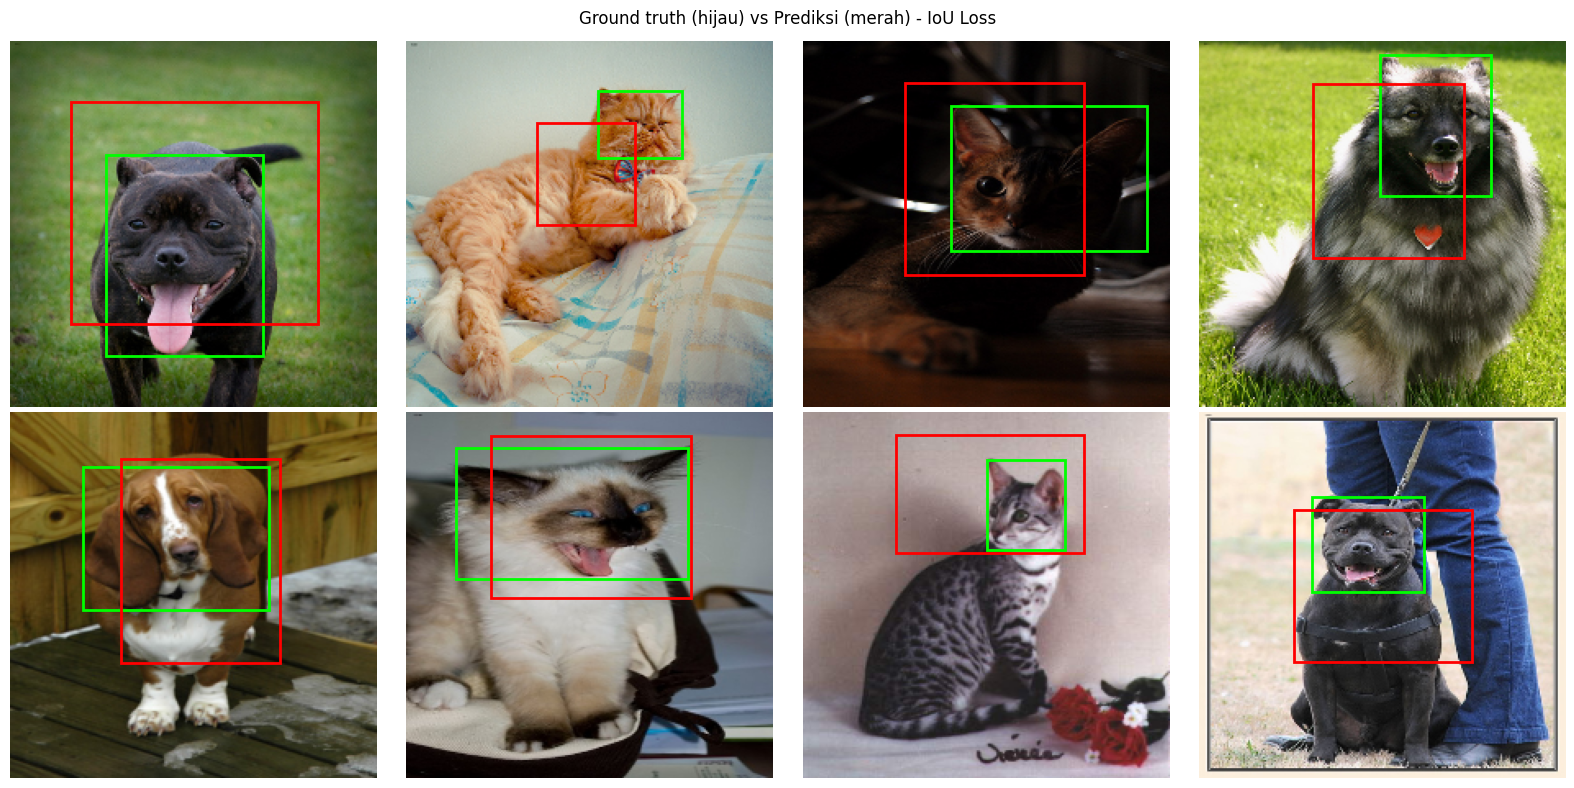

In [8]:
# ==== 8. VISUALISASI PREDIKSI (loss function terbaik) ====
best_name = res_df.iloc[0]['loss_function']
best_model = trained_models[best_name]
print('loss function terbaik:', best_name)

import matplotlib.patches as patches

imgs, boxes_true = next(iter(val_ds.take(1)))
boxes_pred = best_model.predict(imgs)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs):
        break
    ax.imshow(imgs[i].numpy())
    bt = boxes_true[i].numpy() * [IMG_SIZE, IMG_SIZE, IMG_SIZE, IMG_SIZE]
    bp = boxes_pred[i] * [IMG_SIZE, IMG_SIZE, IMG_SIZE, IMG_SIZE]
    ax.add_patch(patches.Rectangle((bt[0], bt[1]), bt[2] - bt[0], bt[3] - bt[1],
                                    edgecolor='lime', facecolor='none', lw=2))
    ax.add_patch(patches.Rectangle((bp[0], bp[1]), bp[2] - bp[0], bp[3] - bp[1],
                                    edgecolor='red', facecolor='none', lw=2))
    ax.axis('off')
plt.suptitle(f'Ground truth (hijau) vs Prediksi (merah) - {best_name}')
plt.tight_layout()
plt.savefig('/content/contoh_prediksi.png', dpi=150)
plt.show()

In [9]:
# ==== 9. SIMPAN + DOWNLOAD MODEL TERBAIK (.keras) - siap load di backend Python ====
from google.colab import files

MODEL_PATH = '/content/bbox_model.keras'
best_model.save(MODEL_PATH)
print('tersimpan di', MODEL_PATH, '| ukuran:', os.path.getsize(MODEL_PATH) / 1e6, 'MB')

files.download(MODEL_PATH)  # trigger download ke laptop lewat browser

tersimpan di /content/bbox_model.keras | ukuran: 11.594218 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# ==== Perbaikan pada GioU/CIoU dan aktivator
def cxcywh_to_xyxy(t):
    cx, cy, w, h = t[..., 0], t[..., 1], t[..., 2], t[..., 3]
    xmin = tf.clip_by_value(cx - w / 2, 0.0, 1.0)
    ymin = tf.clip_by_value(cy - h / 2, 0.0, 1.0)
    xmax = tf.clip_by_value(cx + w / 2, 0.0, 1.0)
    ymax = tf.clip_by_value(cy + h / 2, 0.0, 1.0)
    return tf.stack([xmin, ymin, xmax, ymax], axis=-1)

def build_model(unfreeze_last_n=40):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base.trainable = True
    for layer in base.layers[:-unfreeze_last_n]:
        layer.trainable = False  # freeze mayoritas, fine-tune cuma blok akhir

    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(base.output)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    raw = tf.keras.layers.Dense(4, activation='sigmoid')(x)  # [cx, cy, w, h] semua ternormalisasi 0-1
    out = tf.keras.layers.Lambda(cxcywh_to_xyxy, name='bbox_xyxy')(raw)

    return tf.keras.Model(base.input, out)

build_model().summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 5,240,772 (19.99 MB)

 Trainable params: 4,664,324 (17.79 MB)

 Non-trainable params: 576,448 (2.20 MB)

In [ ]:
# ==== LOSS FUNCTION BOUNDING BOX (formula standar - IoU/GIoU/DIoU/CIoU) ====
def compute_iou(y_true, y_pred, eps=1e-7):
    x1 = tf.maximum(y_true[..., 0], y_pred[..., 0])
    y1 = tf.maximum(y_true[..., 1], y_pred[..., 1])
    x2 = tf.minimum(y_true[..., 2], y_pred[..., 2])
    y2 = tf.minimum(y_true[..., 3], y_pred[..., 3])
    inter = tf.maximum(0.0, x2 - x1) * tf.maximum(0.0, y2 - y1)

    area_t = tf.maximum(0.0, y_true[..., 2] - y_true[..., 0]) * tf.maximum(0.0, y_true[..., 3] - y_true[..., 1])
    area_p = tf.maximum(0.0, y_pred[..., 2] - y_pred[..., 0]) * tf.maximum(0.0, y_pred[..., 3] - y_pred[..., 1])
    union = area_t + area_p - inter + eps
    iou = inter / union
    return iou, union

def mean_iou(y_true, y_pred):
    iou, _ = compute_iou(y_true, y_pred)
    return tf.reduce_mean(iou)

def smooth_l1_loss(y_true, y_pred, beta=1.0):
    diff = tf.abs(y_true - y_pred)
    loss = tf.where(diff < beta, 0.5 * tf.square(diff) / beta, diff - 0.5 * beta)
    return tf.reduce_mean(loss, axis=-1)

def iou_loss(y_true, y_pred):
    iou, _ = compute_iou(y_true, y_pred)
    return 1.0 - iou

def giou_loss(y_true, y_pred, eps=1e-7):
    iou, union = compute_iou(y_true, y_pred, eps)
    xc1 = tf.minimum(y_true[..., 0], y_pred[..., 0])
    yc1 = tf.minimum(y_true[..., 1], y_pred[..., 1])
    xc2 = tf.maximum(y_true[..., 2], y_pred[..., 2])
    yc2 = tf.maximum(y_true[..., 3], y_pred[..., 3])
    area_c = (xc2 - xc1) * (yc2 - yc1) + eps
    giou = iou - (area_c - union) / area_c
    return 1.0 - giou

def diou_loss(y_true, y_pred, eps=1e-7):
    iou, _ = compute_iou(y_true, y_pred, eps)
    xc1 = tf.minimum(y_true[..., 0], y_pred[..., 0])
    yc1 = tf.minimum(y_true[..., 1], y_pred[..., 1])
    xc2 = tf.maximum(y_true[..., 2], y_pred[..., 2])
    yc2 = tf.maximum(y_true[..., 3], y_pred[..., 3])
    c2 = tf.square(xc2 - xc1) + tf.square(yc2 - yc1) + eps  # diagonal enclosing box

    cx_t = (y_true[..., 0] + y_true[..., 2]) / 2
    cy_t = (y_true[..., 1] + y_true[..., 3]) / 2
    cx_p = (y_pred[..., 0] + y_pred[..., 2]) / 2
    cy_p = (y_pred[..., 1] + y_pred[..., 3]) / 2
    rho2 = tf.square(cx_t - cx_p) + tf.square(cy_t - cy_p)

    diou = iou - rho2 / c2
    return 1.0 - diou

def ciou_loss(y_true, y_pred, eps=1e-7):
    iou, _ = compute_iou(y_true, y_pred, eps)
    xc1 = tf.minimum(y_true[..., 0], y_pred[..., 0])
    yc1 = tf.minimum(y_true[..., 1], y_pred[..., 1])
    xc2 = tf.maximum(y_true[..., 2], y_pred[..., 2])
    yc2 = tf.maximum(y_true[..., 3], y_pred[..., 3])
    c2 = tf.square(xc2 - xc1) + tf.square(yc2 - yc1) + eps

    cx_t = (y_true[..., 0] + y_true[..., 2]) / 2
    cy_t = (y_true[..., 1] + y_true[..., 3]) / 2
    cx_p = (y_pred[..., 0] + y_pred[..., 2]) / 2
    cy_p = (y_pred[..., 1] + y_pred[..., 3]) / 2
    rho2 = tf.square(cx_t - cx_p) + tf.square(cy_t - cy_p)

    w_t = y_true[..., 2] - y_true[..., 0]
    h_t = y_true[..., 3] - y_true[..., 1]
    w_p = y_pred[..., 2] - y_pred[..., 0]
    h_p = y_pred[..., 3] - y_pred[..., 1]

    v = (4.0 / (np.pi ** 2)) * tf.square(tf.atan(w_t / (h_t + eps)) - tf.atan(w_p / (h_p + eps)))
    alpha = v / (1.0 - iou + v + eps)

    ciou = iou - (rho2 / c2 + alpha * v)
    return 1.0 - ciou


def make_combo_loss(iou_family_fn, iou_weight=2.0):
    def combo(y_true, y_pred):
        return smooth_l1_loss(y_true, y_pred) + iou_weight * iou_family_fn(y_true, y_pred)
    return combo

smoothl1_ciou_loss = make_combo_loss(ciou_loss)
smoothl1_diou_loss = make_combo_loss(diou_loss)

In [ ]:
# ==== 6. TRAIN + EVALUASI TIAP LOSS FUNCTION ====

EPOCHS = 20

loss_functions = {
    'MSE (baseline)': 'mse',
    'Smooth L1': smooth_l1_loss,
    'IoU Loss': iou_loss,
    'GIoU Loss': giou_loss,
    'DIoU Loss': diou_loss,
    'CIoU Loss': ciou_loss,
    'SmoothL1 + DIoU (gabungan)': smoothl1_diou_loss,
    'SmoothL1 + CIoU (gabungan)': smoothl1_ciou_loss,
}

def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(monitor='val_mean_iou', mode='max', patience=8,
                                          restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_mean_iou', mode='max', factor=0.5,
                                              patience=4, min_lr=1e-6),
    ]

results = []
trained_models = {}
histories = {}
for nama, loss_fn in loss_functions.items():
    print(f'\n=== Training dengan {nama} ===')
    model = build_model()
    opt = tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
    model.compile(optimizer=opt, loss=loss_fn, metrics=[mean_iou])
    hist = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                      callbacks=make_callbacks(), verbose=0)

    val_iou = max(hist.history['val_mean_iou'])
    val_loss = hist.history['val_loss'][hist.history['val_mean_iou'].index(val_iou)]
    results.append({'loss_function': nama, 'val_iou': val_iou, 'val_loss': val_loss,
                     'epochs_ran': len(hist.history['loss'])})
    trained_models[nama] = model
    histories[nama] = hist
    print(f'{nama}: val_loss={val_loss:.4f} | val_mean_IoU={val_iou:.4f} | epoch berhenti di {len(hist.history["loss"])}')


=== Training dengan MSE (baseline) ===
MSE (baseline): val_loss=0.0023 | val_mean_IoU=0.7141 | epoch berhenti di 20

=== Training dengan Smooth L1 ===
Smooth L1: val_loss=0.0010 | val_mean_IoU=0.7357 | epoch berhenti di 20

=== Training dengan IoU Loss ===
IoU Loss: val_loss=0.2732 | val_mean_IoU=0.7270 | epoch berhenti di 20

=== Training dengan GIoU Loss ===
GIoU Loss: val_loss=0.2817 | val_mean_IoU=0.7297 | epoch berhenti di 20

=== Training dengan DIoU Loss ===
DIoU Loss: val_loss=0.2647 | val_mean_IoU=0.7406 | epoch berhenti di 20

=== Training dengan CIoU Loss ===
CIoU Loss: val_loss=0.2831 | val_mean_IoU=0.7249 | epoch berhenti di 20

=== Training dengan SmoothL1 + DIoU (gabungan) ===
SmoothL1 + DIoU (gabungan): val_loss=0.5485 | val_mean_IoU=0.7332 | epoch berhenti di 20

=== Training dengan SmoothL1 + CIoU (gabungan) ===
SmoothL1 + CIoU (gabungan): val_loss=0.5290 | val_mean_IoU=0.7420 | epoch berhenti di 20


                loss_function   val_iou  val_loss  epochs_ran
0  SmoothL1 + CIoU (gabungan)  0.741965  0.528986          20
1                   DIoU Loss  0.740624  0.264693          20
2                   Smooth L1  0.735675  0.000953          20
3  SmoothL1 + DIoU (gabungan)  0.733184  0.548463          20
4                   GIoU Loss  0.729716  0.281748          20
5                    IoU Loss  0.727045  0.273165          20
6                   CIoU Loss  0.724885  0.283119          20
7              MSE (baseline)  0.714066  0.002272          20


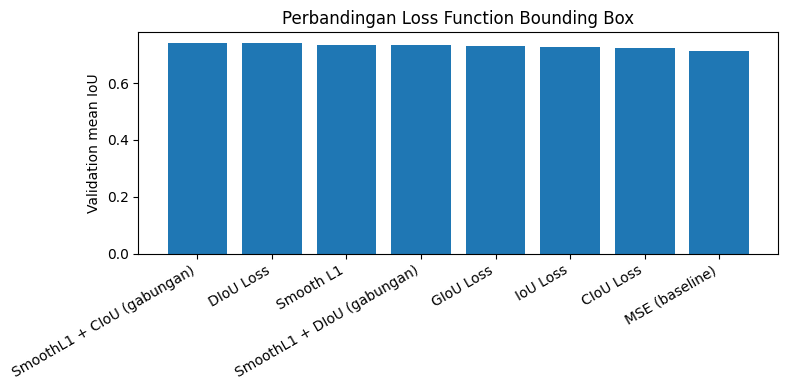

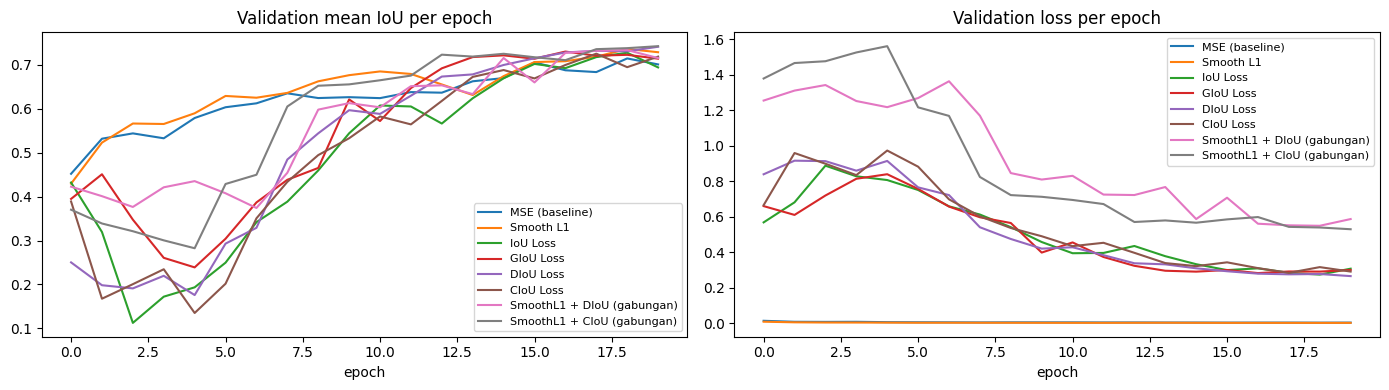

In [ ]:
# ==== 7. TABEL PERBANDINGAN ====
res_df = pd.DataFrame(results).sort_values('val_iou', ascending=False).reset_index(drop=True)
print(res_df)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.bar(res_df['loss_function'], res_df['val_iou'])
plt.ylabel('Validation mean IoU')
plt.title('Perbandingan Loss Function Bounding Box')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('/content/perbandingan_loss.png', dpi=150)
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for nama, hist in histories.items():
    axes[0].plot(hist.history['val_mean_iou'], label=nama)
    axes[1].plot(hist.history['val_loss'], label=nama)
axes[0].set_title('Validation mean IoU per epoch')
axes[0].set_xlabel('epoch'); axes[0].legend(fontsize=8)
axes[1].set_title('Validation loss per epoch')
axes[1].set_xlabel('epoch'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

loss function terbaik: SmoothL1 + CIoU (gabungan)
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


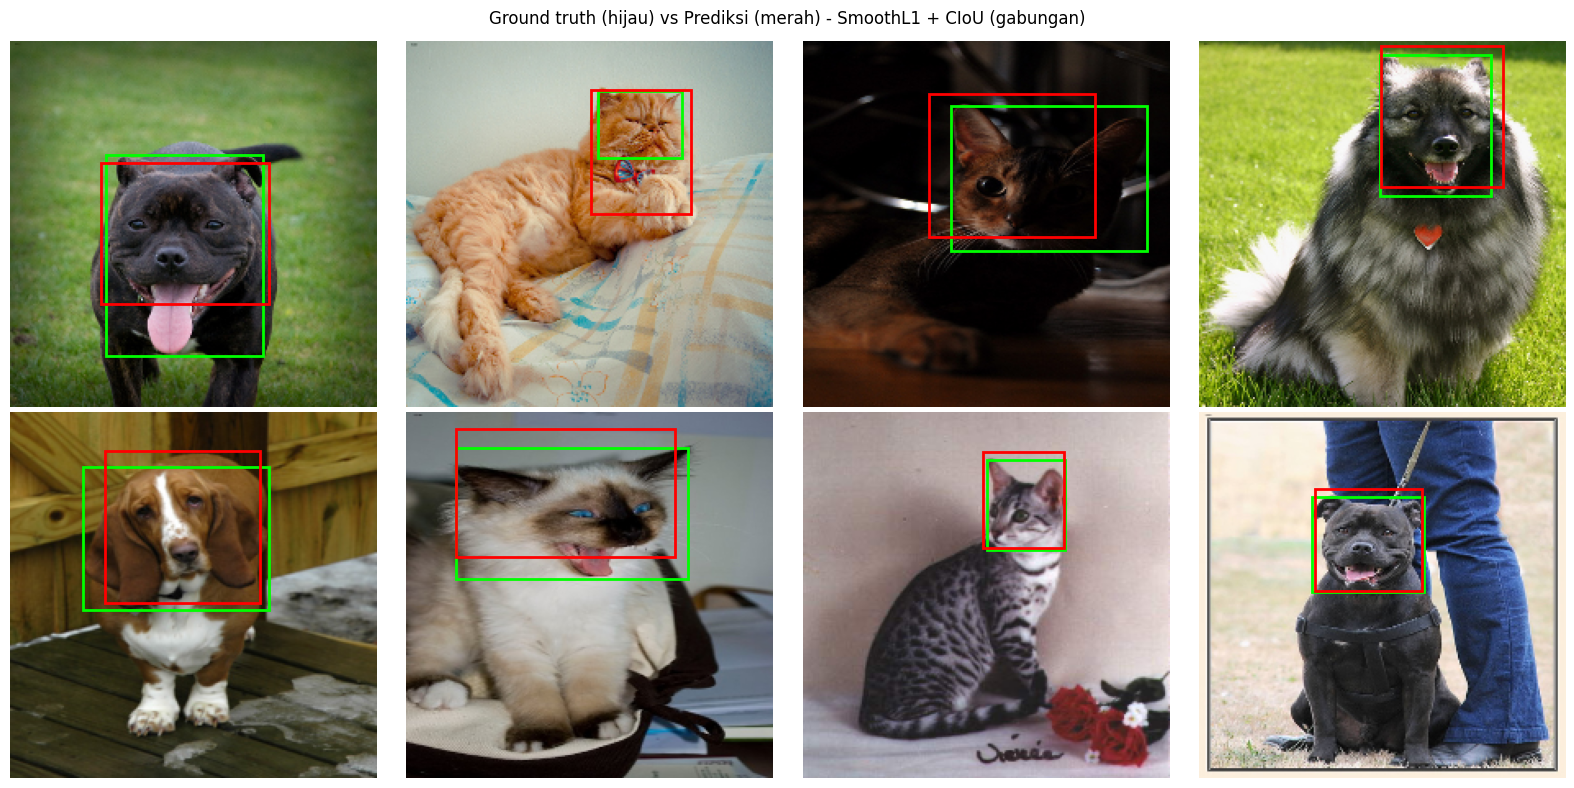

In [16]:
# ==== 8. VISUALISASI PREDIKSI (loss function terbaik) ====
best_name = res_df.iloc[0]['loss_function']
best_model = trained_models[best_name]
print('loss function terbaik:', best_name)

import matplotlib.patches as patches

imgs, boxes_true = next(iter(val_ds.take(1)))
boxes_pred = best_model.predict(imgs)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs):
        break
    ax.imshow(imgs[i].numpy())
    bt = boxes_true[i].numpy() * [IMG_SIZE, IMG_SIZE, IMG_SIZE, IMG_SIZE]
    bp = boxes_pred[i] * [IMG_SIZE, IMG_SIZE, IMG_SIZE, IMG_SIZE]
    ax.add_patch(patches.Rectangle((bt[0], bt[1]), bt[2] - bt[0], bt[3] - bt[1],
                                    edgecolor='lime', facecolor='none', lw=2))
    ax.add_patch(patches.Rectangle((bp[0], bp[1]), bp[2] - bp[0], bp[3] - bp[1],
                                    edgecolor='red', facecolor='none', lw=2))
    ax.axis('off')
plt.suptitle(f'Ground truth (hijau) vs Prediksi (merah) - {best_name}')
plt.tight_layout()
plt.savefig('/content/contoh_prediksi.png', dpi=150)
plt.show()

In [17]:
from google.colab import files

MODEL_PATH = '/content/bbox_calibrate_model.keras'
best_model.save(MODEL_PATH)
print('tersimpan di', MODEL_PATH, '| ukuran:', os.path.getsize(MODEL_PATH) / 1e6, 'MB')

files.download(MODEL_PATH)

tersimpan di /content/bbox_calibrate_model.keras | ukuran: 58.903708 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>